# 实验六：改进针对大模型生成代码的代码审查

## 实验目标
1. 增强上下文构建（新增 Repository 上下文、Issue 信息、完整软件工程上下文）
2. 优化 Prompt 设计（新增 Self-Reflection Prompt）
3. 使用大语言模型（qwen2.5-coder:7b）进行代码审查
4. 与实验五的结果进行对比分析

## 准备工作

### 环境要求
- Ollama 已安装并运行 `qwen2.5-coder:7b` 模型
- 实验五的 AI PR 数据已准备完毕（`lab5/data/ai_pulls/`）

### 导入依赖

In [1]:
import os
import sys
import json

LAB6_DIR = os.path.dirname(os.path.abspath(""))
sys.path.insert(0, LAB6_DIR)
sys.path.insert(0, os.path.join(LAB6_DIR, "..", "lab5"))

import config as cfg
from data_preparer import Lab6DataPreparer

print("✅ 所有模块导入成功！")
print(f"   工作目录: {LAB6_DIR}")
print(f"   MAX_PRS = {cfg.MAX_PRS}, RANDOM_SEED = {cfg.RANDOM_SEED}")

✅ 所有模块导入成功！
   工作目录: f:\学习资料\智能软件工程实践
   MAX_PRS = 100, RANDOM_SEED = 42


---
## 步骤一：数据准备

从实验五的 AI 生成代码 PR 数据中加载原始数据，使用与实验五相同的随机种子（42）采样 100 条 PR，
提取基础字段 + 新增字段（Issue 信息、Repository 上下文字段）。

In [2]:
data, summary = Lab6DataPreparer.run_all(max_prs=cfg.MAX_PRS, seed=cfg.RANDOM_SEED)

  实验六 步骤一：数据准备

[1/4] 从 lab5 加载 AI PR 数据...
  加载 kubernetes_kubernetes: 5 个 AI PR
  加载 pytorch_pytorch: 84 个 AI PR
  加载 tensorflow_tensorflow: 3 个 AI PR
  加载 microsoft_vscode: 183 个 AI PR
  加载 langchain-ai_langchain: 69 个 AI PR
  共加载 344 个 AI PR

[2/4] 随机采样 100 条 PR (seed=42)...
  采样完成: 100/344 条 PR (seed=42)

[3/4] 提取字段（基础字段 + Issue 信息 + Repository 上下文字段）...
  提取完成，共 100 条

[4/4] 计算摘要并保存...

  数据已保存到: f:\学习资料\智能软件工程实践\lab6\data\selected_prs.json
  摘要已保存到: f:\学习资料\智能软件工程实践\lab6\data\selected_prs_summary.json

  步骤一完成!
  总 PR 数:     100
  已合并:       41
  未合并:       59
  含 Issue 引用: 61 条
  平均 Issue 引用: 2.0 个/PR
  总修改文件数: 3554
  平均调用关系: 147.1 个/PR


### 查看数据摘要

In [3]:
print("=" * 50)
print("数据集摘要")
print("=" * 50)
for key, value in summary.items():
    if isinstance(value, dict):
        print(f"\n  {key}:")
        for k, v in value.items():
            print(f"    {k}: {v}")
    elif isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")

数据集摘要
  total_prs: 100
  merged: 41
  not_merged: 59

  repo_counts:
    langchain-ai_langchain: 26
    pytorch_pytorch: 24
    microsoft_vscode: 49
    kubernetes_kubernetes: 1
  total_comments: 295
  avg_diff_length: 166219.76
  prs_with_issue_refs: 61
  avg_issue_refs: 2.00
  total_files: 3554
  avg_related_functions: 147.14


### 查看数据样例

展示第一条 PR 提取后的完整字段，了解数据结构。

In [4]:
import pprint

sample = data[0]
print("=" * 60)
print("数据样例 — 第一条 PR")
print("=" * 60)

print(f"\n📌 基础信息:")
print(f"  PR ID:      {sample['pr_id']}")
print(f"  仓库:       {sample['repo']}")
print(f"  标题:       {sample['pr_title'][:80]}{'...' if len(sample['pr_title']) > 80 else ''}")
print(f"  标签:       {'已合并' if sample['label'] == 1 else '未合并'}")
print(f"  修改文件数: {sample['files_changed']}")
print(f"  新增行数:   {sample['additions']}")
print(f"  删除行数:   {sample['deletions']}")

print(f"\n📁 修改文件列表:")
for fn in sample['file_names'][:5]:
    print(f"  - {fn}")
if len(sample['file_names']) > 5:
    print(f"  ... 共 {len(sample['file_names'])} 个文件")

print(f"\n🔧 修改函数:")
for fn in sample['modified_functions'][:5]:
    print(f"  - {fn}")
if len(sample['modified_functions']) > 5:
    print(f"  ... 共 {len(sample['modified_functions'])} 个函数")

print(f"\n🔗 Issue 引用 (lab6 新增):")
if sample['issue_references']:
    for ref in sample['issue_references'][:3]:
        print(f"  - Issue #{ref['issue_number']} (来源: {ref['source']})")
        print(f"    上下文: {ref['context'][:60]}...")
else:
    print(f"  (无)")

print(f"\n📦 Repository 上下文 (lab6 新增):")
print(f"  文件详情:")
for fwc in sample['files_with_content'][:3]:
    print(f"    - {fwc['filename']} [{fwc['language']}] {fwc['status']}")
    if fwc['modified_functions']:
        print(f"      修改函数: {', '.join(fwc['modified_functions'][:3])}")

print(f"\n  调用关系:")
rf = sample['related_functions']
print(f"    imports: {', '.join(rf['imports'][:5])}{'...' if len(rf['imports']) > 5 else ''}")
print(f"    callees: {', '.join(rf['callees'][:5])}{'...' if len(rf['callees']) > 5 else ''}")

print(f"\n💬 评论统计:")
print(f"  Reviews:        {len(sample['reviews'])} 条")
print(f"  Review Comments: {len(sample['review_comments'])} 条")
print(f"  Issue Comments:  {len(sample['issue_comments'])} 条")

print(f"\n📝 PR 描述 (前 200 字符):")
print(f"  {sample['pr_description'][:200]}{'...' if len(sample['pr_description']) > 200 else ''}")

print(f"\n📄 Diff (前 500 字符):")
if sample['diff']:
    print(sample['diff'][:500])
else:
    print("  (无 diff)")

数据样例 — 第一条 PR

📌 基础信息:
  PR ID:      38401
  仓库:       langchain-ai_langchain
  标题:       fix(langchain): infer openai provider for o4 model name prefix
  标签:       未合并
  修改文件数: 2
  新增行数:   2
  删除行数:   0

📁 修改文件列表:
  - libs/langchain_v1/langchain/chat_models/base.py
  - libs/langchain_v1/tests/unit_tests/chat_models/test_chat_models.py

🔧 修改函数:
  - _attempt_infer_model_provider
  - test_supported_providers_is_sorted

🔗 Issue 引用 (lab6 新增):
  - Issue #38243 (来源: pr_body)
    上下文: Fixes #38243

`init_chat_model("o4-mini")` raised a provider...

📦 Repository 上下文 (lab6 新增):
  文件详情:
    - libs/langchain_v1/langchain/chat_models/base.py [Python] modified
      修改函数: _attempt_infer_model_provider
    - libs/langchain_v1/tests/unit_tests/chat_models/test_chat_models.py [Python] modified
      修改函数: test_supported_providers_is_sorted

  调用关系:
    imports: 
    callees: 

💬 评论统计:
  Reviews:        0 条
  Review Comments: 0 条
  Issue Comments:  1 条

📝 PR 描述 (前 200 字符):
  Fixes #38243

`init_chat_mo

### Issue 引用统计

了解数据集中有多少 PR 关联了 Issue，这是支撑 "Diff + Issue 信息" 上下文的关键。

In [5]:
prs_with_issues = [d for d in data if d['issue_references']]
prs_without_issues = [d for d in data if not d['issue_references']]

print(f"含 Issue 引用的 PR: {len(prs_with_issues)} 条 ({len(prs_with_issues)/len(data)*100:.1f}%)")
print(f"无 Issue 引用的 PR: {len(prs_without_issues)} 条 ({len(prs_without_issues)/len(data)*100:.1f}%)")

if prs_with_issues:
    all_refs = []
    for d in prs_with_issues:
        for ref in d['issue_references']:
            all_refs.append(ref['issue_number'])
    print(f"\nIssue 引用总数: {len(all_refs)} 个")
    print(f"平均每 PR Issue 引用: {len(all_refs)/len(prs_with_issues):.1f} 个")
    print(f"唯一 Issue 编号: {len(set(all_refs))} 个")

含 Issue 引用的 PR: 61 条 (61.0%)
无 Issue 引用的 PR: 39 条 (39.0%)

Issue 引用总数: 200 个
平均每 PR Issue 引用: 3.3 个
唯一 Issue 编号: 188 个


### 仓库分布

In [6]:
print("=" * 50)
print("仓库分布")
print("=" * 50)
repo_counts = summary['repo_counts']
for repo, count in sorted(repo_counts.items(), key=lambda x: -x[1]):
    bar = "█" * (count // 2)
    print(f"  {repo:<30} {count:>3}  {bar}")

仓库分布
  microsoft_vscode                49  ████████████████████████
  langchain-ai_langchain          26  █████████████
  pytorch_pytorch                 24  ████████████
  kubernetes_kubernetes            1  


---
## 步骤一完成

数据已保存到 `lab6/data/selected_prs.json`，共 100 条 PR，每条包含：

| 字段类别 | 字段 | 说明 |
|---------|------|------|
| 基础 | `pr_id`, `repo`, `pr_title`, `pr_description`, `diff`, `commit_message`, `label` | 与 lab5 一致 |
| 基础 | `file_names`, `modified_functions`, `historical_comments_text` | 与 lab5 一致 |
| 基础 | `reviews`, `review_comments`, `issue_comments` | 与 lab5 一致 |
| **新增** | `issue_references` | Issue 引用编号 + 来源 + 上下文 |
| **新增** | `files_with_content` | 每个修改文件的详细信息（patch、语言、状态） |
| **新增** | `related_functions` | 调用关系（imports + callees） |

下一步：步骤二 — 上下文构建。

---
## 步骤二：上下文构建

构建 5 种不同粒度的软件工程上下文：
- `diff_only`：仅代码 Diff
- `diff_pr_desc`：Diff + PR 描述
- `diff_repo`：Diff + Repository 上下文（文件信息 + 调用关系）
- `diff_issue`：Diff + Issue 信息
- `diff_full`：完整软件工程上下文（融合所有信息）

In [7]:
from context_builder import (
    run_context_building,
    print_context_stats,
    print_context_sample,
    CONTEXT_TYPES,
)

print("✅ context_builder 模块导入成功！")
print(f"   5 种上下文类型: {CONTEXT_TYPES}")

✅ context_builder 模块导入成功！
   5 种上下文类型: ['diff_only', 'diff_pr_desc', 'diff_repo', 'diff_issue', 'diff_full']


In [8]:
contexts, ctx_stats = run_context_building(data)

  实验六 步骤二：上下文构建
  5 种上下文类型: ['diff_only', 'diff_pr_desc', 'diff_repo', 'diff_issue', 'diff_full']
  输入 PR 数: 100

  已处理 50/100 条...
  已处理 100/100 条...
  上下文构建完成，共 100 条
  上下文数据已保存到: f:\学习资料\智能软件工程实践\lab6\data\contexts.json
  文件大小: 84.93 MB


### 上下文长度统计

In [9]:
print_context_stats(ctx_stats)

各上下文类型长度统计
上下文                  样本数      最小       最大       平均         总字符         
------------------------------------------------------------
diff_only            100      19       14,700,628 166,220    16,622,014  
diff_pr_desc         100      904      14,700,741 167,803    16,780,282  
diff_repo            100      65       15,401,936 175,296    17,529,649  
diff_issue           100      542      14,702,770 167,473    16,747,259  
diff_full            100      2,256    15,405,172 179,079    17,907,913  


### 上下文样例展示

展示第一条 PR 在 5 种上下文下的完整内容（截断显示）。

In [10]:
print_context_sample(contexts, idx=0)


上下文样例 — PR #38401 (langchain-ai_langchain)  label=0

[diff_only]  长度: 786 字符
  预览: --- a/libs/langchain_v1/langchain/chat_models/base.py\n+++ b/libs/langchain_v1/langchain/chat_models/base.py\n@@ -536,6 +536,7 @@ def _attempt_infer_model_provider(model_name: str) -> str | None:\n      ...

[diff_pr_desc]  长度: 1,169 字符
  预览: # Pull Request\n\n## Title\nfix(langchain): infer openai provider for o4 model name prefix\n\n## Description\nFixes #38243\n\n`init_chat_model("o4-mini")` raised a provider inference error because `_attempt_i...

[diff_repo]  长度: 1,127 字符
  预览: # Repository Context\n\n## Changed Files\n  - libs/langchain_v1/langchain/chat_models/base.py  [Python]  modified  (+1 -0)\n  - libs/langchain_v1/tests/unit_tests/chat_models/test_chat_models.py  [Python]...

[diff_issue]  长度: 1,839 字符
  预览: # Issue Context\n\n## Referenced Issues\n### Issue #38243\nSource: pr_body\nContext: Fixes #38243\n\n`init_chat_model("o4-mini")` raised a provider i\n\n\n## Related Discussions\n**githu

In [11]:
c = contexts[0]
print("=" * 60)
print("完整上下文样例 — PR #{} ({})".format(c['pr_id'], c['repo']))
print("=" * 60)

for ct in CONTEXT_TYPES:
    text = c["contexts"][ct]
    print(f"\n{'─' * 60}")
    print(f"  [{ct}]  长度: {len(text):,} 字符")
    print(f"{'─' * 60}")
    print(text[:800])
    if len(text) > 800:
        print(f"\n  ... (省略 {len(text) - 800:,} 字符)")

完整上下文样例 — PR #38401 (langchain-ai_langchain)

────────────────────────────────────────────────────────────
  [diff_only]  长度: 786 字符
────────────────────────────────────────────────────────────
--- a/libs/langchain_v1/langchain/chat_models/base.py
+++ b/libs/langchain_v1/langchain/chat_models/base.py
@@ -536,6 +536,7 @@ def _attempt_infer_model_provider(model_name: str) -> str | None:
             "gpt-",
             "o1",
             "o3",
+            "o4",
             "chatgpt",
             "text-davinci",
         )
--- a/libs/langchain_v1/tests/unit_tests/chat_models/test_chat_models.py
+++ b/libs/langchain_v1/tests/unit_tests/chat_models/test_chat_models.py
@@ -81,6 +81,7 @@ def test_supported_providers_is_sorted() -> None:
     [
         (OPENAI_TEST_MODEL, "openai"),
         ("o3", "openai"),
+        ("o4-mini", "openai"),
         ("text-davinci-003", "openai"),
         ("claude-3-haiku-20240307", "anthropic"),
         ("command-r-plus", "cohere"),

──────────────────

### 上下文长度对比

对比各上下文类型的长度分布，了解不同上下文的信息量差异。

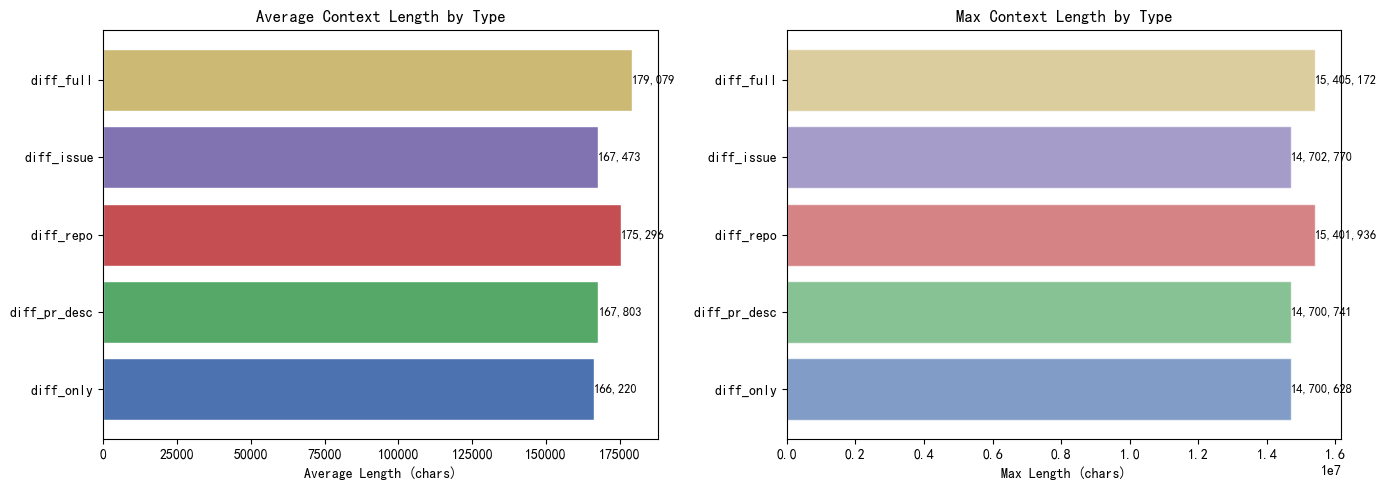

In [12]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = CONTEXT_TYPES
means = [ctx_stats[ct]['mean'] for ct in CONTEXT_TYPES]
maxs = [ctx_stats[ct]['max'] for ct in CONTEXT_TYPES]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

axes[0].barh(labels, means, color=colors, edgecolor='white')
axes[0].set_xlabel('Average Length (chars)')
axes[0].set_title('Average Context Length by Type')
for i, v in enumerate(means):
    axes[0].text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)

axes[1].barh(labels, maxs, color=colors, edgecolor='white', alpha=0.7)
axes[1].set_xlabel('Max Length (chars)')
axes[1].set_title('Max Context Length by Type')
for i, v in enumerate(maxs):
    axes[1].text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 步骤二完成

上下文数据已保存到 `lab6/data/contexts.json`，共 100 条 PR，每条包含 5 种上下文。

| 上下文类型 | 说明 | 数据来源 |
|-----------|------|---------|
| `diff_only` | 仅代码 Diff | `diff` 字段 |
| `diff_pr_desc` | Diff + PR 描述 | `diff` + `pr_title` + `pr_description` |
| `diff_repo` | Diff + Repository 上下文 | `diff` + `files_with_content` + `related_functions` |
| `diff_issue` | Diff + Issue 信息 | `diff` + `issue_references` + `issue_comments` |
| `diff_full` | 完整软件工程上下文 | 所有字段融合 |

下一步：步骤三 — Prompt 设计。

---
## 步骤三：Prompt 设计

针对不同上下文设计 4 种 Prompt 策略：
- `role_based`：角色扮演 Prompt（资深 committer 视角）
- `few_shot`：少样本示例 Prompt（2 个示例引导）
- `cot`：思维链 Prompt（5 步推理 + 优化解析格式）
- `self_reflection`：自我反思 Prompt（单次调用两阶段：初始判断 → 反思 → 最终判断）

两个任务：
- `merge_prediction`：合并预测
- `review_comment`：审查评论生成

共 4 × 2 = 8 个 Prompt 模板。

In [13]:
from prompt_builder import (
    build_prompt,
    build_all_prompts,
    print_prompt_examples,
    print_full_prompt_example,
    PROMPT_TYPES,
    FEW_SHOT_EXAMPLE_MERGE_1,
    FEW_SHOT_EXAMPLE_MERGE_2,
    FEW_SHOT_EXAMPLE_REVIEW_1,
    FEW_SHOT_EXAMPLE_REVIEW_2,
)

print("✅ prompt_builder 模块导入成功！")
print(f"   4 种 Prompt 类型: {PROMPT_TYPES}")
print(f"   任务: merge_prediction, review_comment")
print(f"   共 {len(PROMPT_TYPES) * 2} 个 Prompt 模板")

✅ prompt_builder 模块导入成功！
   4 种 Prompt 类型: ['role_based', 'few_shot', 'cot', 'self_reflection']
   任务: merge_prediction, review_comment
   共 8 个 Prompt 模板


### Few-shot 示例展示

In [14]:
print("=" * 60)
print("Merge Prediction 示例 1 (Yes):")
print("=" * 60)
print(FEW_SHOT_EXAMPLE_MERGE_1)

print("\n" + "=" * 60)
print("Merge Prediction 示例 2 (No):")
print("=" * 60)
print(FEW_SHOT_EXAMPLE_MERGE_2)

print("\n" + "=" * 60)
print("Review Comment 示例 1:")
print("=" * 60)
print(FEW_SHOT_EXAMPLE_REVIEW_1)

print("\n" + "=" * 60)
print("Review Comment 示例 2:")
print("=" * 60)
print(FEW_SHOT_EXAMPLE_REVIEW_2)

Merge Prediction 示例 1 (Yes):
Example 1:
Code Change:
@@ -10,6 +10,6 @@ def calculate(a, b):
-    return a + b
+    if b == 0:
+        return 0
+    return a + b
Output:
{"decision": "Yes", "reason": "Added division-by-zero guard, improves robustness with clear logic"}

Merge Prediction 示例 2 (No):
Example 2:
Code Change:
@@ -1,5 +1,15 @@ import os
+import subprocess
+
 def process(data):
-    result = data.strip()
+    result = subprocess.check_output(data, shell=True)
     return result
Output:
{"decision": "No", "reason": "Using shell=True introduces command injection risk without input validation"}

Review Comment 示例 1:
Example 1:
Code Change:
@@ -10,7 +10,7 @@ def calculate(a, b):
-    return a + b
+    if b == 0:
+        return 0
+    return a + b
Review Comment: Consider extracting the zero-check logic into a separate helper function and adding unit tests for edge cases (b=0, negative values).

Review Comment 示例 2:
Example 2:
Code Change:
@@ -20,6 +20,10 @@ class UserService:
  

### Prompt 样例概览

使用 `diff_pr_desc` 上下文展示 4 种 Prompt 的截断预览。

In [15]:
print_prompt_examples(contexts, context_type="diff_pr_desc")

Prompt Examples (Merge Prediction, diff_pr_desc)

--- role_based ---
  Length: 1,676 chars
  Preview: You are a senior committer at the Apache Software Foundation with 10 years of experience reviewing large-scale open-source projects. Your review standards are extremely strict. Code must be:\n- Logically correct and bug-free\n- Consistent with project coding conventions\n- Well-tested with adequate coverage\n- Free of security vulnerabilities\n\nReview the following code change and determine if it passe...

--- few_shot ---
  Length: 2,011 chars
  Preview: Determine whether the following Pull Request code change is likely to be merged.\n\nHere are two examples to guide your judgment and output format:\n\nExample 1:\nCode Change:\n@@ -10,6 +10,6 @@ def calculate(a, b):\n-    return a + b\n+    if b == 0:\n+        return 0\n+    return a + b\nOutput:\n{"decision": "Yes", "reason": "Added division-by-zero guard, improves robustness with clear logic"}\n\nExample 2:\n...

--- cot ---
  Len

### Self-Reflection Prompt 完整示例

展示 lab6 核心创新 — Self-Reflection Prompt 的完整内容。

In [16]:
print_full_prompt_example(
    contexts,
    task="merge_prediction",
    prompt_type="self_reflection",
    context_type="diff_pr_desc"
)

Full Prompt: task=merge_prediction, type=self_reflection, context=diff_pr_desc
Length: 2,045 chars
You are a code reviewer. For the following code change, perform a TWO-STAGE review:

STAGE 1 — INITIAL JUDGMENT:
Make your initial assessment about whether this PR should be merged. Consider correctness, security, code style, and maintainability.

STAGE 2 — SELF-REFLECTION:
Critically examine your initial judgment. Ask yourself:
- Did I miss any edge cases or potential bugs?
- Did I overlook security concerns?
- Did I consider code style and maintainability?
- Is my reasoning consistent with the evidence?
If you find any issues, correct them in your final judgment.

IMPORTANT: Output EXACTLY in this format, with each section clearly marked:

[INITIAL JUDGMENT]
{"decision": "Yes" or "No", "reason": "brief reason"}

[REFLECTION]
Your critical self-review of the initial judgment...

[FINAL JUDGMENT]
{"decision": "Yes" or "No", "reason": "final reason"}

Code Change:
# Pull Request

## Title


In [17]:
print("\n" + "=" * 60)
print("Review Comment 的 Self-Reflection Prompt:")
print("=" * 60)
print_full_prompt_example(
    contexts,
    task="review_comment",
    prompt_type="self_reflection",
    context_type="diff_pr_desc"
)


Review Comment 的 Self-Reflection Prompt:
Full Prompt: task=review_comment, type=self_reflection, context=diff_pr_desc
Length: 1,932 chars
You are a code reviewer. For the following code change, perform a TWO-STAGE review:

STAGE 1 — INITIAL REVIEW:
Write your initial review comment for this code change. Consider correctness, security, style, readability, and maintainability.

STAGE 2 — SELF-REFLECTION:
Critically examine your review comment. Ask yourself:
- Did I provide specific, actionable feedback?
- Did I miss any important issues?
- Is my tone constructive and professional?
- Did I suggest concrete improvements?
If you find issues, improve your review comment.

IMPORTANT: Output EXACTLY in this format:

[INITIAL REVIEW]
Your initial review comment...

[REFLECTION]
Your critical self-review of the initial comment...

[FINAL REVIEW]
Your improved, final review comment...

Code Change:
# Pull Request

## Title
fix(langchain): infer openai provider for o4 model name prefix

## Descri

### 各 Prompt 类型长度对比

对比 4 种 Prompt 类型在不同上下文下的长度。

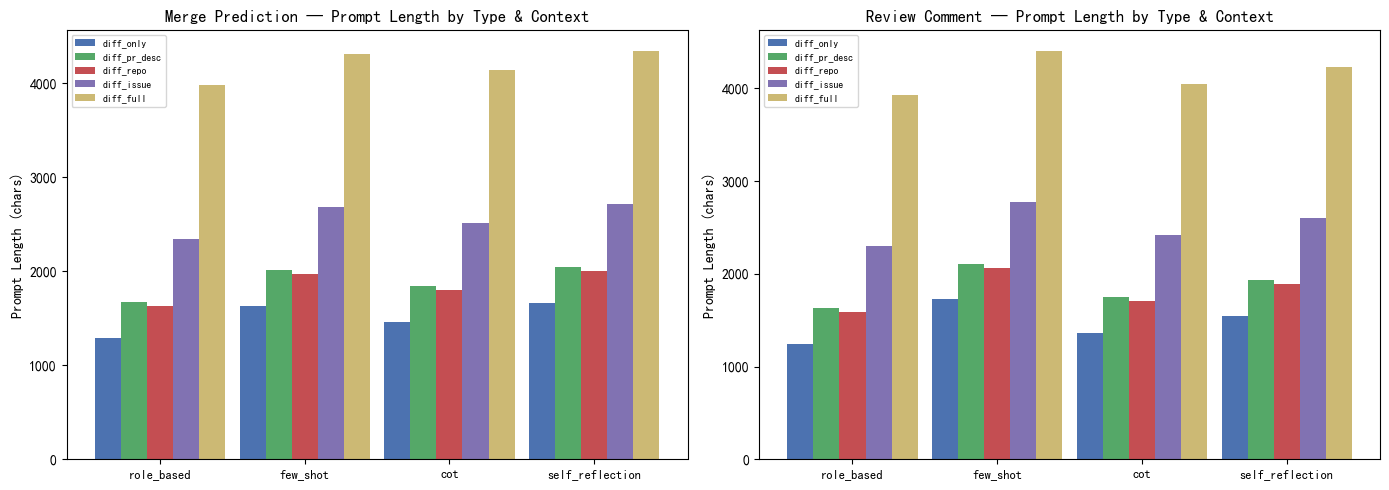

In [18]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

if contexts:
    c = contexts[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Merge Prediction
    data_merge = {}
    for ct in CONTEXT_TYPES:
        data_merge[ct] = []
        for pt in PROMPT_TYPES:
            prompt = build_prompt(c["contexts"][ct], "merge_prediction", pt)
            data_merge[ct].append(len(prompt))
    
    x = range(len(PROMPT_TYPES))
    width = 0.18
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
    
    for i, ct in enumerate(CONTEXT_TYPES):
        axes[0].bar([p + i * width for p in x], data_merge[ct], width, 
                    label=ct, color=colors[i])
    
    axes[0].set_xticks([p + width * 2 for p in x])
    axes[0].set_xticklabels(PROMPT_TYPES, fontsize=9)
    axes[0].set_ylabel('Prompt Length (chars)')
    axes[0].set_title('Merge Prediction — Prompt Length by Type & Context')
    axes[0].legend(fontsize=7, loc='upper left')
    
    # Review Comment
    data_review = {}
    for ct in CONTEXT_TYPES:
        data_review[ct] = []
        for pt in PROMPT_TYPES:
            prompt = build_prompt(c["contexts"][ct], "review_comment", pt)
            data_review[ct].append(len(prompt))
    
    for i, ct in enumerate(CONTEXT_TYPES):
        axes[1].bar([p + i * width for p in x], data_review[ct], width,
                    label=ct, color=colors[i])
    
    axes[1].set_xticks([p + width * 2 for p in x])
    axes[1].set_xticklabels(PROMPT_TYPES, fontsize=9)
    axes[1].set_ylabel('Prompt Length (chars)')
    axes[1].set_title('Review Comment — Prompt Length by Type & Context')
    axes[1].legend(fontsize=7, loc='upper left')
    
    plt.tight_layout()
    plt.show()

### 验证所有 Prompt 模板

遍历所有组合，确保 8 个模板都能正常生成。

In [19]:
if contexts:
    c = contexts[0]
    ctx = c["contexts"]["diff_pr_desc"]
    
    print("验证 8 个 Prompt 模板:")
    print("-" * 50)
    
    for task in ["merge_prediction", "review_comment"]:
        for pt in PROMPT_TYPES:
            prompt = build_prompt(ctx, task, pt)
            status = "✅" if len(prompt) > 0 else "❌"
            print(f"  {status}  {task:<20}  {pt:<18}  {len(prompt):>8,} chars")

验证 8 个 Prompt 模板:
--------------------------------------------------
  ✅  merge_prediction      role_based             1,676 chars
  ✅  merge_prediction      few_shot               2,011 chars
  ✅  merge_prediction      cot                    1,842 chars
  ✅  merge_prediction      self_reflection        2,045 chars
  ✅  review_comment        role_based             1,631 chars
  ✅  review_comment        few_shot               2,109 chars
  ✅  review_comment        cot                    1,747 chars
  ✅  review_comment        self_reflection        1,932 chars


---
## 步骤三完成

Prompt 模板已就绪，共 4 种 Prompt 类型 × 2 个任务 = 8 个模板：

| Prompt 类型 | Merge Prediction | Review Comment |
|------------|-----------------|----------------|
| `role_based` | 资深 committer → JSON | 资深 committer → 评论 |
| `few_shot` | 2 示例 → JSON | 2 示例 → 评论 |
| `cot` | 5 步推理 → JSON | 5 步推理 → 评论 |
| `self_reflection` | 两阶段反思 → JSON | 两阶段反思 → 评论 |

与 lab4 的区别：
- ❌ 移除了 `zero_shot`（lab5 中 Yes 偏向严重）
- 🆕 新增 `self_reflection`（初始判断 → 自我反思 → 最终判断）
- 🔧 `cot` 优化了解析格式（显式要求 final json on separate line）

下一步：步骤四 — LLM 模型推理。

---
## 步骤四：LLM 模型推理

利用设计好的上下文和 Prompt 调用大语言模型，分别完成：
- **Merge Prediction**：预测 PR 是否会被合并
- **Review Comment Generation**：生成代码审查评论

实验矩阵：**5 上下文 × 4 Prompt × 2 任务 = 40 组实验**

特性：
- 每组独立保存到 JSON 文件，支持断点续传
- 每 10 条自动保存
- Self-Reflection 输出特殊解析（提取 [FINAL JUDGMENT]）

In [20]:
from llm_inference import (
    call_llm,
    parse_merge_result,
    parse_self_reflection_merge,
    parse_self_reflection_review,
    run_all_experiments,
    run_single_experiment,
    save_results,
    print_result_summary,
    load_all_results,
    CONTEXT_TYPES,
    PROMPT_TYPES,
    TASKS,
)

import config

print("✅ llm_inference 模块导入成功！")
print(f"   上下文类型: {len(CONTEXT_TYPES)} 种 → {CONTEXT_TYPES}")
print(f"   Prompt 类型: {len(PROMPT_TYPES)} 种 → {PROMPT_TYPES}")
print(f"   任务类型: {len(TASKS)} 种 → {TASKS}")
print(f"   总实验组数: {len(CONTEXT_TYPES) * len(PROMPT_TYPES) * len(TASKS)} 组")
print(f"   最大 API 调用: {len(contexts) * len(CONTEXT_TYPES) * len(PROMPT_TYPES) * len(TASKS)} 次")
print(f"\n   LLM 配置:")
print(f"     提供商: {config.LLM_PROVIDER}")
if config.LLM_PROVIDER == "ollama":
    print(f"     模型: {config.OLLAMA_MODEL}")
    print(f"     Temperature: {config.OLLAMA_TEMPERATURE}")
    print(f"     Max Tokens: {config.OLLAMA_MAX_TOKENS}")
else:
    print(f"     模型: {config.OPENAI_MODEL}")
    print(f"     Temperature: {config.OPENAI_TEMPERATURE}")
    print(f"     Max Tokens: {config.OPENAI_MAX_TOKENS}")
    print(f"     Thinking: {config.OPENAI_THINKING}")
print(f"     Max Prompt Chars: {config.MAX_PROMPT_CHARS:,}")

✅ llm_inference 模块导入成功！
   上下文类型: 5 种 → ['diff_only', 'diff_pr_desc', 'diff_repo', 'diff_issue', 'diff_full']
   Prompt 类型: 4 种 → ['few_shot', 'cot', 'role_based', 'self_reflection']
   任务类型: 2 种 → ['merge_prediction', 'review_comment']
   总实验组数: 40 组
   最大 API 调用: 4000 次

   LLM 配置:
     提供商: openai
     模型: GLM-4.7-Flash
     Temperature: 1.0
     Max Tokens: 65536
     Thinking: True
     Max Prompt Chars: 25,000


### 实验矩阵总览

In [21]:
print("实验矩阵 (5 上下文 × 4 Prompt × 2 任务):")
print("=" * 70)

group = 0
for task in TASKS:
    print(f"\n{'─' * 70}")
    print(f"  Task: {task}")
    print(f"{'─' * 70}")
    print(f"  {'Context':<18} {'Prompt':<18} {'预计记录':<10}")
    print(f"  {'─' * 46}")
    for ct in CONTEXT_TYPES:
        for pt in PROMPT_TYPES:
            group += 1
            print(f"  {ct:<18} {pt:<18} {len(contexts):<10}")

print(f"\n总组数: {group}")
print(f"最大 API 调用: {group * len(contexts)} 次")

实验矩阵 (5 上下文 × 4 Prompt × 2 任务):

──────────────────────────────────────────────────────────────────────
  Task: merge_prediction
──────────────────────────────────────────────────────────────────────
  Context            Prompt             预计记录      
  ──────────────────────────────────────────────
  diff_only          few_shot           100       
  diff_only          cot                100       
  diff_only          role_based         100       
  diff_only          self_reflection    100       
  diff_pr_desc       few_shot           100       
  diff_pr_desc       cot                100       
  diff_pr_desc       role_based         100       
  diff_pr_desc       self_reflection    100       
  diff_repo          few_shot           100       
  diff_repo          cot                100       
  diff_repo          role_based         100       
  diff_repo          self_reflection    100       
  diff_issue         few_shot           100       
  diff_issue         cot             

### 🚀 执行 LLM 推理

**注意**：这将调用 Ollama 模型，共 40 组实验，最多 4000 次 API 调用。
每组结果保存到独立 JSON 文件，中断后重跑会自动跳过已完成记录。

In [ ]:
all_results = run_all_experiments(contexts)


组 1/8: merge_prediction + few_shot
  文件: f:\学习资料\智能软件工程实践\lab6\results\step4\merge_prediction_few_shot.json


[merge_prediction][few_shot]:   1%|    | 7/500 [02:31<2:38:35, 19.30s/req, new=7, lat=19.3s, skip=0]

  [OpenAI 调用失败] 429 Too Many Requests (Retry-After: N/A)，1s 后重试 (1/3)


[merge_prediction][few_shot]:   2%|    | 8/500 [02:58<2:58:40, 21.79s/req, new=8, lat=25.4s, skip=0]

  [OpenAI 调用失败] 429 Too Many Requests (Retry-After: N/A)，1s 后重试 (1/3)


...

[merge_prediction][few_shot]:   2%|  | 10/500 [03:44<3:03:23, 22.46s/req, new=10, lat=18.8s, skip=0]

  [OpenAI 调用失败] 429 Too Many Requests (Retry-After: N/A)，1s 后重试 (1/3)
  [OpenAI 调用失败] 429 Too Many Requests (Retry-After: N/A)，2s 后重试 (2/3)


[merge_prediction][few_shot]:   5%|  | 26/500 [08:15<1:44:30, 13.23s/req, new=26, lat=12.0s, skip=0]

  [OpenAI 调用失败] 429 Too Many Requests (Retry-After: N/A)，1s 后重试 (1/3)


[merge_prediction][few_shot]:   7%|▏ | 36/500 [11:45<3:42:30, 28.77s/req, new=36, lat=54.6s, skip=0]

### 保存汇总结果

In [ ]:
save_results(all_results)

### 推理结果汇总

In [ ]:
print_result_summary(all_results)

---
## 步骤四完成

推理结果已保存到 `lab6/results/step4/` 目录：

| 文件 | 内容 |
|------|------|
| `merge_prediction_*.json` | 4 个 Prompt 的合并预测结果 |
| `review_comment_*.json` | 4 个 Prompt 的审查评论结果 |
| `all_results.json` | 汇总结果 |

每条记录包含：`pr_id`, `repo`, `label`, `task`, `context_type`, `prompt_type`, `output_raw`, `output_decision`/`output_comment`, `parse_error`, `latency`

下一步：步骤五 — 结果分析。

---
## 步骤五：结果分析

统计不同方法的实验结果，包括：
- **分类指标**：Accuracy、Precision、Recall、F1-score、ROC-AUC
- **生成指标**：BLEU、ROUGE-L
- **推理时间**：平均延迟

分析不同上下文和 Prompt 设计对代码审查性能的影响，并与实验五进行对比。

In [ ]:
from analyze_results import (
    run_analysis,
    print_merge_section,
    print_merge_summary_table,
    print_unknown_source_analysis,
    print_review_summary_table,
    compare_merge_with_lab5,
    compare_review_with_lab5,
    load_lab5_results,
    analyze_merge_prediction,
    analyze_review_comment,
    compute_bleu,
    compute_rouge_l,
    _tokenize,
)

print("✅ analyze_results 模块导入成功！")

### 🚀 运行完整分析

自动执行：结果分析 → 跨 Prompt 汇总 → 与 lab5 对比

In [ ]:
all_merge_stats, all_review_stats = run_analysis()

### lab6 vs lab5 对比可视化

绘制 lab6 与 lab5 在 Merge Prediction 上的对比柱状图。

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

lab5_merge, lab5_review = load_lab5_results()

if lab5_merge:
    prompt_mapping = {
        "few_shot": "few_shot",
        "cot": "cot",
        "role_based": "role_based",
        "self_reflection": "zero_shot",
    }
    
    metrics = ["accuracy", "precision", "recall", "f1"]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        lab6_values = []
        lab5_values = []
        labels = []
        
        for pt in PROMPT_TYPES:
            l5_pt = prompt_mapping.get(pt)
            if pt not in all_merge_stats or l5_pt not in lab5_merge:
                continue
            
            l6_data = lab5_merge[l5_pt]
            l6_cm = compute_classification_metrics(l6_data)
            l5_cm = all_merge_stats[pt]["cls_metrics"]
            
            if l5_cm is None:
                continue
            
            v6 = l5_cm.get(metric)
            v5 = l6_cm.get(metric) if l6_cm else None
            
            if v6 is not None and v5 is not None:
                lab6_values.append(v6)
                lab5_values.append(v5)
                labels.append(pt)
        
        if not labels:
            continue
        
        x = np.arange(len(labels))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, lab6_values, width, label='lab6', color='#4C72B0')
        bars2 = ax.bar(x + width/2, lab5_values, width, label='lab5', color='#DD8452')
        
        ax.set_ylabel(metric.upper())
        ax.set_title(f'{metric.upper()} Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ax.legend()
        ax.set_ylim(0, 1.0)
        
        for bar in bars1:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=8)
        for bar in bars2:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.2f}',
                    ha='center', va='bottom', fontsize=8)
    
    plt.suptitle('lab6 vs lab5 — Merge Prediction Metrics Comparison', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

---
## 步骤五完成

实验六全部完成！总结：

| 步骤 | 内容 | 输出 |
|------|------|------|
| 步骤一 | 数据准备 | `lab6/data/selected_prs.json` |
| 步骤二 | 上下文构建 | `lab6/data/contexts.json` |
| 步骤三 | Prompt 设计 | `lab6/prompt_builder.py` |
| 步骤四 | LLM 推理 | `lab6/results/step4/*.json` |
| 步骤五 | 结果分析 | 控制台输出 + 图表 |

核心创新：
- 🆕 5 种上下文粒度（新增 Repository 上下文、Issue 信息、完整上下文）
- 🆕 Self-Reflection Prompt（两阶段自我反思）
- 🔧 优化的 CoT 解析格式
- 📊 与 lab5 的全面对比分析